In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_6_natural = get_prompt("natural", 6)

prompt_6_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure, and compute the RMSD, SASA, and radius of gyration of the simulation.'

In [3]:
llm_model = "gpt-3.5-turbo-0125"
tools = "all"

In [5]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_6_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...
Thought: The task involves simulating the protein 1LYZ for 1ps at 300 K, analyzing its secondary structure, and calculating RMSD, SASA, and radius of gyration. I will need to set up the simulation, analyze the secondary structure, and compute the required properties.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ",
        "forcefield_files": ["amber14/protein.ff14SB.xml", "amber14/tip3p.xml"],
        "save": true,
        "system_params": {
            "nonbondedMethod": "NoCutoff",
            "constraints": "HBonds",
            "rigidWater": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Friction": "1.0 / picoseconds",
            "Timestep": "0.002 * picoseconds",
            "Pressure": "1.0 * bar"
        },
        "simulation_params": {
            "Ensemble": "NVT",
            "Num

<Figure size 640x480 with 0 Axes>

In [7]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_150818: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_150818
 rec0_150819: dssp values for trajectory with id: 1LYZ_150818
 sasa_1LYZ_150818: Total SASA values for 1LYZ_150818
 rgy_1LYZ_150818: Radii of gyration per frame for 1LYZ_150818
 fig0_150823: Plot of radii of gyration over time for 1LYZ_150818


In [9]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_150818"))

In [10]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_150818", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [12]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_125315")
top_path = registry.get_mapped_path("top_sim0_023025")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

AssertionError: 

In [15]:
# # make sure rmsd plot was generated
# from IPython.display import Image
# Image(filename=registry.get_mapped_path('fig0_022913'))

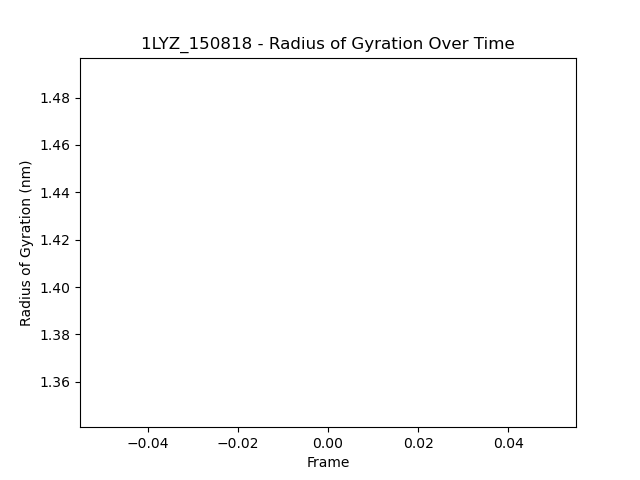

In [16]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_150823'))

In [ ]:
# # make sure sasa plot was generated
# from IPython.display import Image
# Image(filename=registry.get_mapped_path('fig0_023320'))

In [17]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 76596
Output tokens: 1200
LLM costs: $ 0.040098
